# View the arithmetic datasets

Load, filter, and inspect the frozen training-run datasets (`scripts/make_data.py`).

| file       | ops | format   | labels  | notes |
|------------|-----|----------|---------|-------|
| `D_algo`   | + - | nl       | correct | natural-language add/sub |
| `D_inst`   | *   | operator | random  | operator-format mult, random labels |
| `D_target` | + - | operator | correct | operator-format add/sub |
| `probe`    | + - | operator | correct | held-out eval set (64/cell) |

Use `show(...)` below to filter by **format** (`nl` / `operator`) and **op** (`add`/`sub`/`mult` or `+`/`-`/`*`).

In [1]:
import subprocess, sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 120)

# ---- config: edit these ----
SCALE = 'pilot'          # 'pilot' (10k/dataset) or 'full' (1M/dataset)
SEED = 20260717

# find repo root by walking up until we see the geode/ package
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'geode').is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

# point DATA_DIR at your own parquet dir to view the real run instead
DATA_DIR = REPO_ROOT / 'experiments' / 'training-run' / 'notebooks' / 'data' / SCALE

print('repo root :', REPO_ROOT)
print('data dir  :', DATA_DIR)

repo root : /home/mhieuuu/Github/geode
data dir  : /home/mhieuuu/Github/geode/experiments/training-run/notebooks/data/pilot


In [2]:
# generate the pilot if the parquet files are not there yet (CPU-only, no GPU/budget gate)
FILES = ['D_algo', 'D_inst', 'D_target', 'probe']
missing = [f for f in FILES if not (DATA_DIR / (f + '.parquet')).exists()]

if missing:
    print('generating', SCALE, 'dataset (missing:', missing, ')...')
    script = REPO_ROOT / 'experiments' / 'training-run' / 'scripts' / 'make_data.py'
    subprocess.run(
        [sys.executable, str(script), '--scale', SCALE, '--out', str(DATA_DIR), '--seed', str(SEED)],
        check=True,
    )
else:
    print('found existing parquet in', DATA_DIR)

found existing parquet in /home/mhieuuu/Github/geode/experiments/training-run/notebooks/data/pilot


In [3]:
# load all four files into one combined frame
df = pd.concat([pd.read_parquet(DATA_DIR / (n + '.parquet')) for n in FILES], ignore_index=True)
df['op_word'] = df['op'].map({'+': 'add', '-': 'sub', '*': 'mult'})

print('total rows:', len(df))
df.groupby(['dataset', 'format', 'label_mode', 'op']).size().rename('rows').reset_index()

total rows: 31024


,dataset,format,label_mode,op,rows
0,D_algo,nl,correct,+,5001
1,D_algo,nl,correct,-,4999
2,D_inst,operator,random,*,10000
3,D_target,operator,correct,+,5001
4,D_target,operator,correct,-,4999
5,probe,operator,correct,+,512
6,probe,operator,correct,-,512


## Filter

`show(fmt=..., op=..., dataset=..., n=...)` — every argument is optional; omit one to keep it unfiltered.
- `fmt`: `'nl'` or `'operator'`
- `op`: `'add'`/`'sub'`/`'mult'` (or `'+'`/`'-'`/`'*'`)
- `dataset`: `'D_algo'`, `'D_inst'`, `'D_target'`, `'probe'`

In [4]:
OP_ALIASES = {'add': '+', 'sub': '-', 'subtract': '-', 'minus': '-',
              'mult': '*', 'multiply': '*', 'times': '*',
              '+': '+', '-': '-', '*': '*'}

def show(fmt=None, op=None, dataset=None, n=10, data=None):
    'Filter the combined frame by format / op / dataset and return the first n matching rows.'
    out = df if data is None else data
    if fmt is not None:
        out = out[out['format'] == fmt]
    if op is not None:
        out = out[out['op'] == OP_ALIASES[op]]
    if dataset is not None:
        out = out[out['dataset'] == dataset]
    print('matched', len(out), 'rows for', dict(fmt=fmt, op=op, dataset=dataset))
    cols = ['dataset', 'a', 'op', 'b', 'cell', 'format', 'label_mode',
            'true_answer', 'shown_answer', 'full_text']
    return out[cols].head(n)

In [5]:
# natural-language rows
show(fmt='nl', n=5)

matched 10000 rows for {'fmt': 'nl', 'op': None, 'dataset': None}


,dataset,a,op,b,cell,format,label_mode,true_answer,shown_answer,full_text
0,D_algo,572,+,9875,3x4,nl,correct,10447,10447,Question: What is the sum of 572 and 9875?\nAnswer: 10447
1,D_algo,5605,-,26,4x2,nl,correct,5579,5579,Question: What is the difference between 5605 and 26?\nAnswer: 5579
2,D_algo,3,-,7,1x1,nl,correct,-4,-4,Question: What is the difference between 3 and 7?\nAnswer: -4
3,D_algo,6,-,4481,1x4,nl,correct,-4475,-4475,Question: What is the difference between 6 and 4481?\nAnswer: -4475
4,D_algo,9,+,4585,1x4,nl,correct,4594,4594,Question: What is the sum of 9 and 4585?\nAnswer: 4594


In [6]:
# multiplication rows (operator format, random labels)
show(op='mult', n=5)

matched 10000 rows for {'fmt': None, 'op': 'mult', 'dataset': None}


,dataset,a,op,b,cell,format,label_mode,true_answer,shown_answer,full_text
10000,D_inst,996,*,535,3x3,operator,random,532860,566698,Question: 996 * 535\nAnswer: 566698
10001,D_inst,87,*,9911,2x4,operator,random,862257,214577,Question: 87 * 9911\nAnswer: 214577
10002,D_inst,634,*,7,3x1,operator,random,4438,6463,Question: 634 * 7\nAnswer: 6463
10003,D_inst,6,*,605,1x3,operator,random,3630,4024,Question: 6 * 605\nAnswer: 4024
10004,D_inst,68,*,170,2x3,operator,random,11560,20901,Question: 68 * 170\nAnswer: 20901


In [7]:
# operator-format subtraction, correct labels
show(op='sub', fmt='operator', n=5)

matched 5511 rows for {'fmt': 'operator', 'op': 'sub', 'dataset': None}


,dataset,a,op,b,cell,format,label_mode,true_answer,shown_answer,full_text
20000,D_target,362,-,611,3x3,operator,correct,-249,-249,Question: 362 - 611\nAnswer: -249
20001,D_target,29,-,9,2x1,operator,correct,20,20,Question: 29 - 9\nAnswer: 20
20002,D_target,49,-,9,2x1,operator,correct,40,40,Question: 49 - 9\nAnswer: 40
20004,D_target,27,-,8139,2x4,operator,correct,-8112,-8112,Question: 27 - 8139\nAnswer: -8112
20005,D_target,3544,-,46,4x2,operator,correct,3498,3498,Question: 3544 - 46\nAnswer: 3498


## Distribution across digit-cells

How many rows land in each `x_digits x y_digits` cell, per dataset.

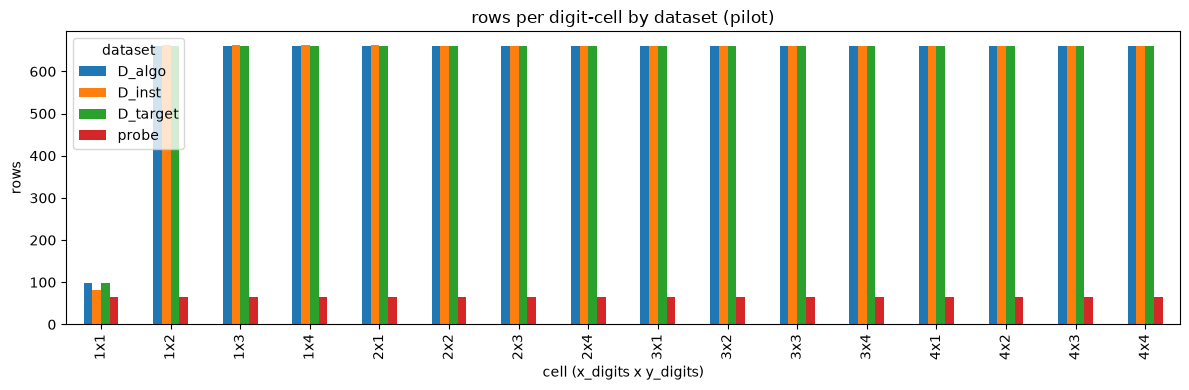

In [8]:
counts = df.groupby(['cell', 'dataset']).size().unstack('dataset').fillna(0)
counts = counts.reindex(sorted(counts.index, key=lambda c: (int(c[0]), int(c[2]))))
ax = counts.plot(kind='bar', figsize=(12, 4))
ax.set_xlabel('cell (x_digits x y_digits)')
ax.set_ylabel('rows')
ax.set_title('rows per digit-cell by dataset (' + SCALE + ')')
plt.tight_layout()
plt.show()